In [1]:
# Cell 1: Enable auto-reload (optional, but great for development)
%load_ext autoreload
%autoreload 2
from datasets import load_dataset
import duckdb as ddb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime


# Cell 2: Import your modules
import utilities.aggregate_customers as agg
import utilities.visualize_energy_consumption as viz

In [2]:
ds = load_dataset("thuml/UTSD", "UTSD-1G")

Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

In [3]:
# the dataset have not been divided into train, test, and val splits
# therefore, ds['train'] contains all the time series
# you can split them by yourself, or use our default split as train:val=9:1 in '''utsdataset.py'''
all = ds['train']

# print the total number of time series
print(f'total {len(all)} single-variate series')

# each item is a single-variate series containing:
# 1. dataset name (item_id)
# 2. start time (start)
# 3. end time (end)
# 4. sampling frequecy (freq)
# 5. time series values (target)
# timestampes are optional since some datasets are irregular and may not have

# see https://huggingface.co/datasets/thuml/UTSD/viewer for more details`
print(all[0].keys())

# you can access the time series values by item['target']
num_timepoints = len(all[0]['target'])
print(f'the first time series containing {num_timepoints} time points')

# or generate the timestamps by item['start'], item['end'], and item['freq']

print(all[0])

df = pd.DataFrame(all)


total 68679 single-variate series
dict_keys(['item_id', 'start', 'end', 'freq', 'target'])
the first time series containing 896 time points
{'item_id': 'Health_SelfRegulationSCP1_458_0', 'start': '', 'end': '', 'freq': '', 'target': [-8.119999885559082, -11.5600004196167, -14.279999732971191, -18.190000534057617, -20.030000686645508, -20.84000015258789, -20.09000015258789, -19.5, -18.059999465942383, -17.25, -18.34000015258789, -17.40999984741211, -18.719999313354492, -19.8799991607666, -19.3799991607666, -19.719999313354492, -19.34000015258789, -17.780000686645508, -16.40999984741211, -17.3799991607666, -15.970000267028809, -16.969999313354492, -18.34000015258789, -20.969999313354492, -23.219999313354492, -26.90999984741211, -28.219999313354492, -28.940000534057617, -30.84000015258789, -30.84000015258789, -30.280000686645508, -28.530000686645508, -26.65999984741211, -21.969999313354492, -17.559999465942383, -13.59000015258789, -13.0600004196167, -13.8100004196167, -14.59000015258789, 

In [5]:
con = ddb.connect(database=':memory:')

In [10]:
smart_meter_df = con.execute("""
    SELECT * FROM df WHERE item_id LIKE '%meter%';
""").fetch_df()

smart_meter_df.head()

smart_meter_cust = con.execute("""
    SELECT COUNT(DISTINCT item_id) FROM df WHERE item_id LIKE '%meter%';
""").fetchone()

print(f"Number of smart meter customers: {smart_meter_cust[0]}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Number of smart meter customers: 60


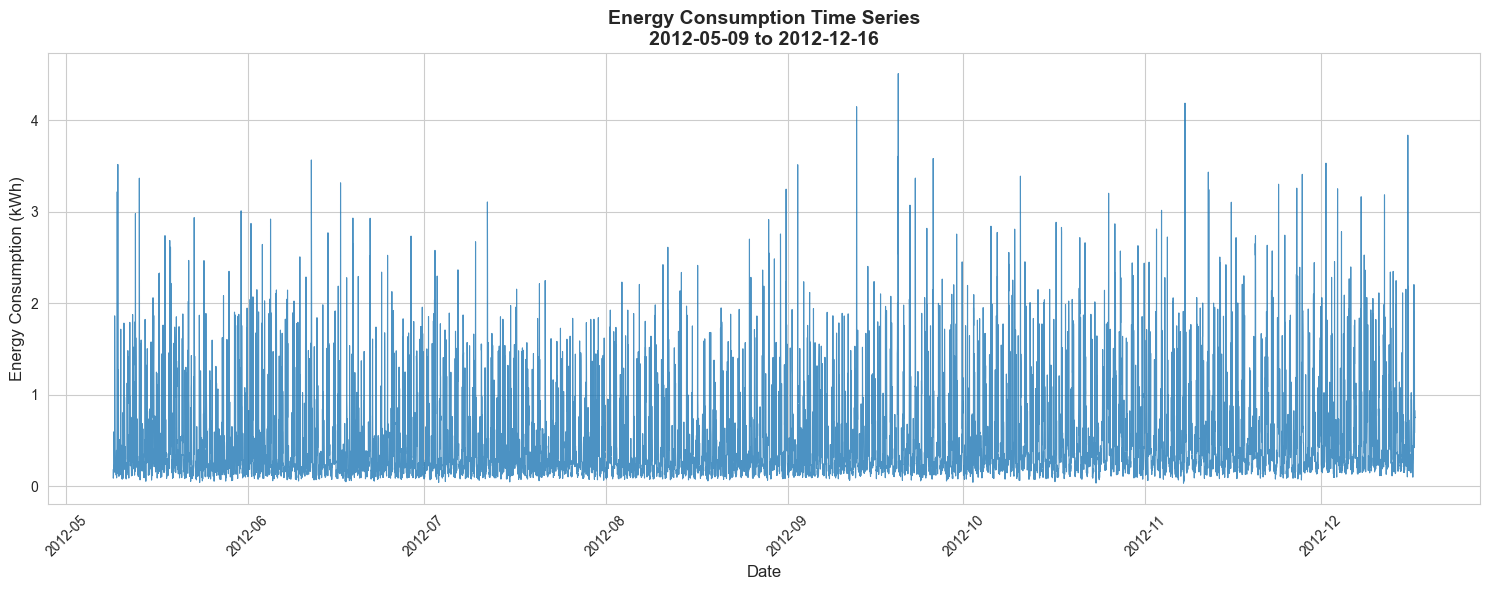

In [12]:
fig, df = viz.visualize_single_series(smart_meter_df.iloc[0])

In [ ]:
# Check the first few rows
for i in range(3):
    row = smart_meter_df.iloc[i]
    start = pd.to_datetime(row['start'])
    end = pd.to_datetime(row['end'])
    n_points = len(row['target'])

    # Calculate total time span
    time_span = end - start

    # Calculate expected frequency
    avg_interval = time_span / (n_points - 1)

    print(f"Row {i}:")
    print(f"  Start: {start}")
    print(f"  End: {end}")
    print(f"  Points: {n_points}")
    print(f"  Time span: {time_span}")
    print(f"  Avg interval: {avg_interval}")
    print(f"  Freq column: {row['freq']}")
    print()

Row 0:
  Start: 2012-05-09 00:00:01
  End: 2012-12-16 23:30:01
  Points: 10656
  Time span: 221 days 23:30:00
  Avg interval: 0 days 00:30:00
  Freq column: M

Row 1:
  Start: 2012-10-12 00:00:01
  End: 2014-02-23 23:30:01
  Points: 24000
  Time span: 499 days 23:30:00
  Avg interval: 0 days 00:30:00
  Freq column: M

Row 2:
  Start: 2012-10-04 00:00:01
  End: 2014-02-24 23:30:01
  Points: 24432
  Time span: 508 days 23:30:00
  Avg interval: 0 days 00:30:00
  Freq column: M

